# Etapa 2 — Modelagem com Redes Neurais (MLP PyTorch)

**Tech Challenge Fase 01** — Previsão de Churn em Telecomunicações

## Objetivo
Construir, treinar e avaliar uma MLP com PyTorch, comparando com os baselines
da Etapa 1 e analisando trade-offs de custo.

In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import mlflow
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_curve, precision_recall_curve, roc_auc_score
)

from src.data.load_data import load_raw_data, preprocess_raw_data
from src.features.pipeline import prepare_features, build_preprocessor
from src.models.mlp import ChurnMLP, train_mlp, predict_mlp
from src.models.baseline import compute_metrics, train_baselines
from src.utils.reproducibility import set_seeds, GLOBAL_SEED

set_seeds(GLOBAL_SEED)
sns.set_theme(style='whitegrid')

print(f'PyTorch version: {torch.__version__}')
print(f'Device: {"cuda" if torch.cuda.is_available() else "cpu"}')

PyTorch version: 2.11.0+cu130
Device: cpu


## 1. Preparação dos Dados

In [2]:
# Carregar e preprocessar
df = pd.read_csv('../data/raw/telco_churn.csv')
df_clean = preprocess_raw_data(df)
X, y = prepare_features(df_clean)

# Splits
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=GLOBAL_SEED, stratify=y
)
X_train_mlp, X_val, y_train_mlp, y_val = train_test_split(
    X_train, y_train, test_size=0.15, random_state=GLOBAL_SEED, stratify=y_train
)

# Preprocessar features
preprocessor = build_preprocessor()
X_train_proc = preprocessor.fit_transform(X_train_mlp)
X_val_proc = preprocessor.transform(X_val)
X_test_proc = preprocessor.transform(X_test)

print(f'Train: {X_train_proc.shape}')
print(f'Val: {X_val_proc.shape}')
print(f'Test: {X_test_proc.shape}')

2026-05-04 15:24:37 [info     ] preprocessamento_iniciado     


2026-05-04 15:24:37 [info     ] preprocessamento_concluido     churn_rate=26.54% colunas=20 linhas=7043


2026-05-04 15:24:37 [info     ] features_preparadas            X_shape=(7043, 19) y_shape=(7043,)


2026-05-04 15:24:37 [info     ] preprocessor_construido        cat_features=15 num_features=4


Train: (4788, 45)
Val: (846, 45)
Test: (1409, 45)


## 2. Treinamento da MLP

In [3]:
# Calcular peso da classe para desbalanceamento
n_pos = y_train_mlp.sum()
n_neg = len(y_train_mlp) - n_pos
class_weight = n_neg / n_pos
print(f'Class weight (pos): {class_weight:.2f}')

# Treinar MLP
mlflow.set_experiment('churn-prediction-mlp')

with mlflow.start_run(run_name='mlp_training'):
    model, history = train_mlp(
        X_train_proc,
        y_train_mlp.values.astype(np.float32),
        X_val_proc,
        y_val.values.astype(np.float32),
        epochs=200,
        batch_size=64,
        learning_rate=1e-3,
        weight_decay=1e-4,
        patience=15,
        class_weight=class_weight,
    )
    
    mlflow.log_params({
        'architecture': '128-64-32-1',
        'epochs_max': 200,
        'batch_size': 64,
        'learning_rate': 1e-3,
        'weight_decay': 1e-4,
        'patience': 15,
        'class_weight': f'{class_weight:.2f}',
    })
    mlflow.log_metric('epochs_trained', history['epochs_trained'])

print(f'\nTreinamento concluído em {history["epochs_trained"]} épocas')

Class weight (pos): 2.77


2026/05/04 15:24:38 INFO mlflow.tracking.fluent: Experiment with name 'churn-prediction-mlp' does not exist. Creating a new experiment.


2026-05-04 15:24:38 [info     ] dispositivo_selecionado        device=cpu


2026-05-04 15:24:42 [info     ] epoch_concluida                epoch=10 train_loss=0.7056 val_loss=0.7567


2026-05-04 15:24:44 [info     ] epoch_concluida                epoch=20 train_loss=0.6835 val_loss=0.7728


2026-05-04 15:24:45 [info     ] early_stopping_ativado         epoch=24


2026-05-04 15:24:45 [info     ] treinamento_concluido          epochs_treinadas=24



Treinamento concluído em 24 épocas


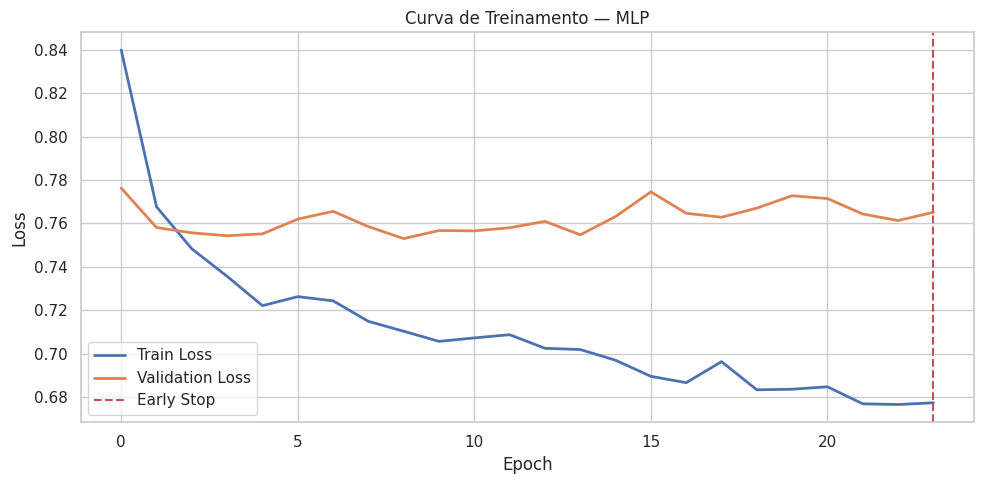

In [4]:
# Curva de treinamento
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(history['train_loss'], label='Train Loss', linewidth=2)
ax.plot(history['val_loss'], label='Validation Loss', linewidth=2)
ax.axvline(x=history['epochs_trained']-1, color='r', linestyle='--', label='Early Stop')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.set_title('Curva de Treinamento — MLP')
ax.legend()
plt.tight_layout()
plt.savefig('../docs/training_curve.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Avaliação no Conjunto de Teste

In [5]:
# Predição
y_pred, y_prob = predict_mlp(model, X_test_proc)
mlp_metrics = compute_metrics(y_test.values, y_pred, y_prob)

print('=== MLP — Métricas no Teste ===')
for metric, value in mlp_metrics.items():
    print(f'  {metric}: {value:.4f}')

print('\n=== Classification Report ===')
print(classification_report(y_test.values, y_pred, target_names=['No Churn', 'Churn']))

=== MLP — Métricas no Teste ===
  accuracy: 0.7686
  precision: 0.5513
  recall: 0.6898
  f1: 0.6128
  roc_auc: 0.8409

=== Classification Report ===
              precision    recall  f1-score   support

    No Churn       0.88      0.80      0.84      1035
       Churn       0.55      0.69      0.61       374

    accuracy                           0.77      1409
   macro avg       0.71      0.74      0.72      1409
weighted avg       0.79      0.77      0.78      1409



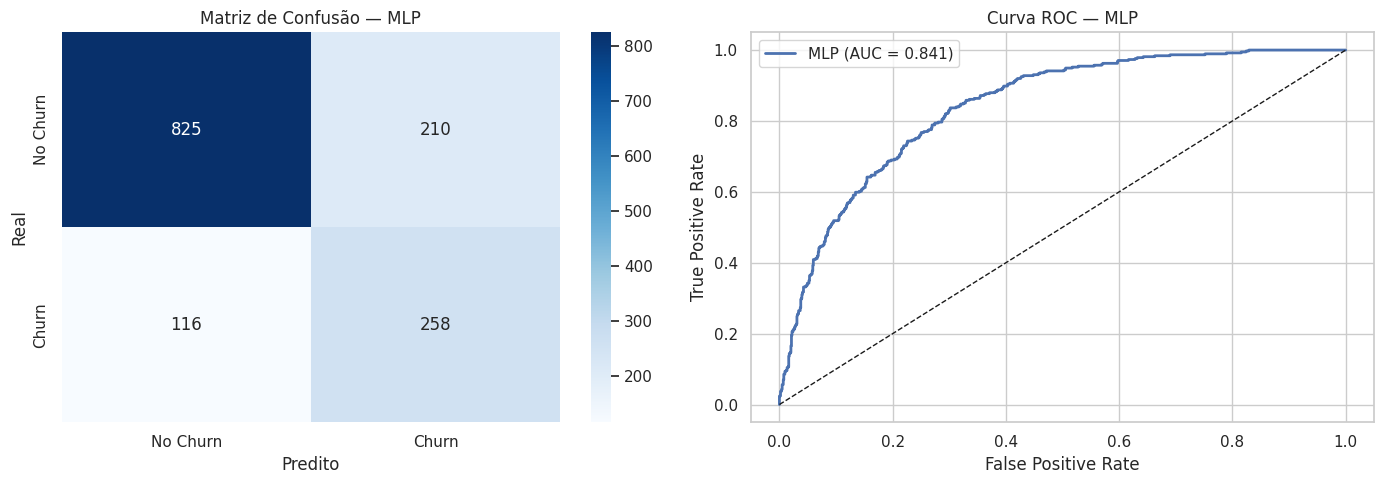

In [6]:
# Matriz de confusão
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion matrix
cm = confusion_matrix(y_test.values, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['No Churn', 'Churn'],
            yticklabels=['No Churn', 'Churn'])
axes[0].set_title('Matriz de Confusão — MLP')
axes[0].set_xlabel('Predito')
axes[0].set_ylabel('Real')

# ROC Curve
fpr, tpr, _ = roc_curve(y_test.values, y_prob)
auc = roc_auc_score(y_test.values, y_prob)
axes[1].plot(fpr, tpr, linewidth=2, label=f'MLP (AUC = {auc:.3f})')
axes[1].plot([0, 1], [0, 1], 'k--', linewidth=1)
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('Curva ROC — MLP')
axes[1].legend()

plt.tight_layout()
plt.savefig('../docs/mlp_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Comparação MLP vs Baselines (≥ 4 métricas)

In [7]:
# Treinar baselines para comparação justa no mesmo test set
baseline_results = train_baselines(X_train, y_train.values)

# Adicionar MLP
all_results = {**baseline_results, 'MLP (PyTorch)': mlp_metrics}

# Tabela comparativa
comparison_df = pd.DataFrame(all_results).T
comparison_df = comparison_df.round(4)
comparison_df = comparison_df.sort_values('roc_auc', ascending=False)

print('\n=== TABELA COMPARATIVA DE MODELOS ===')
print(comparison_df.to_string())
comparison_df

2026-05-04 15:24:46 [info     ] preprocessor_construido        cat_features=15 num_features=4


2026-05-04 15:24:46 [info     ] treinando_baseline             modelo=DummyClassifier


2026-05-04 15:24:47 [info     ] baseline_avaliado              accuracy=0.61395101171459 f1=0.2762063227953411 modelo=DummyClassifier precision=0.27483443708609273 recall=0.27759197324414714 roc_auc=0.5065176585234991


2026-05-04 15:24:47 [info     ] treinando_baseline             modelo=LogisticRegression


2026-05-04 15:24:52 [info     ] baseline_avaliado              accuracy=0.7484913028044018 f1=0.6283766063467087 modelo=LogisticRegression precision=0.5168248490077653 recall=0.8013377926421404 roc_auc=0.8454670113230783


...

2026-05-04 15:24:58 [info     ] baseline_avaliado              accuracy=0.7855875044373447 f1=0.5378729915837797 modelo=RandomForest precision=0.6282394995531725 recall=0.47023411371237456 roc_auc=0.820660799750477


2026-05-04 15:24:58 [info     ] treinando_baseline             modelo=GradientBoosting


2026-05-04 15:25:07 [info     ] baseline_avaliado              accuracy=0.8031593894213702 f1=0.5878855444072836 modelo=GradientBoosting precision=0.6613712374581939 recall=0.5290969899665552 roc_auc=0.8474236825497894



=== TABELA COMPARATIVA DE MODELOS ===
                    accuracy  precision  recall      f1  roc_auc
GradientBoosting      0.8032     0.6614  0.5291  0.5879   0.8474
LogisticRegression    0.7485     0.5168  0.8013  0.6284   0.8455
MLP (PyTorch)         0.7686     0.5513  0.6898  0.6128   0.8409
RandomForest          0.7856     0.6282  0.4702  0.5379   0.8207
DummyClassifier       0.6140     0.2748  0.2776  0.2762   0.5065


,accuracy,precision,recall,f1,roc_auc
GradientBoosting,0.8032,0.6614,0.5291,0.5879,0.8474
LogisticRegression,0.7485,0.5168,0.8013,0.6284,0.8455
MLP (PyTorch),0.7686,0.5513,0.6898,0.6128,0.8409
RandomForest,0.7856,0.6282,0.4702,0.5379,0.8207
DummyClassifier,0.6140,0.2748,0.2776,0.2762,0.5065


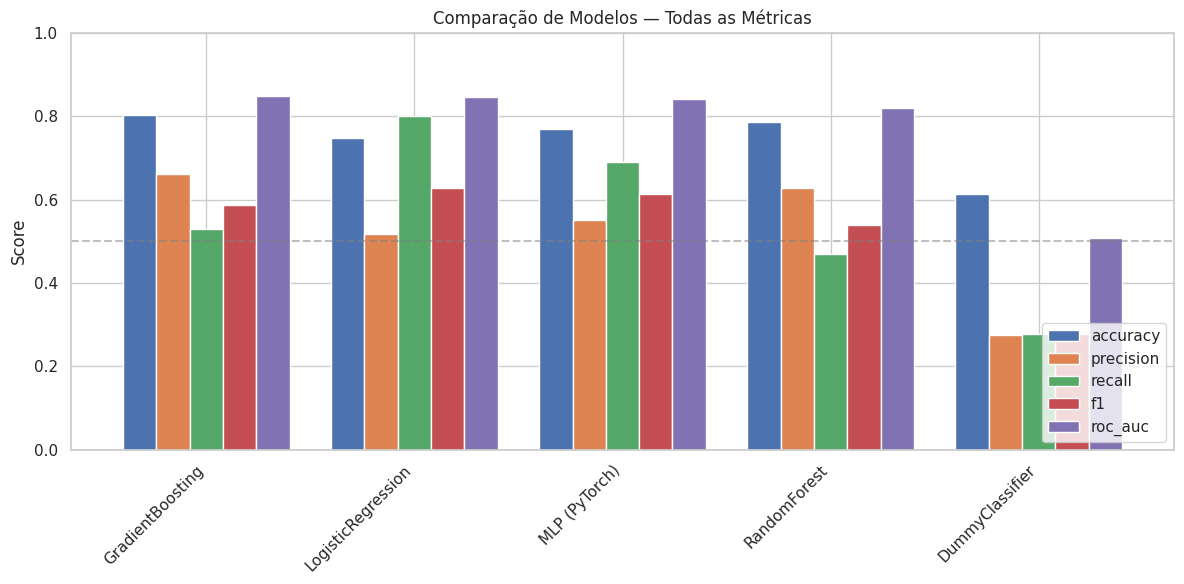

In [8]:
# Visualização da comparação
fig, ax = plt.subplots(figsize=(12, 6))
comparison_df.plot(kind='bar', ax=ax, width=0.8)
ax.set_title('Comparação de Modelos — Todas as Métricas')
ax.set_ylabel('Score')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
ax.legend(loc='lower right')
ax.set_ylim(0, 1)
ax.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('../docs/models_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Análise de Trade-off de Custo (FP vs FN)

In [9]:
# Análise de custo
# Premissas:
# - Custo de Falso Negativo (cliente churn não detectado): R$ 500/mês (perda do cliente)
# - Custo de Falso Positivo (oferta de retenção desnecessária): R$ 50/mês

COST_FN = 500  # Custo de perder um cliente
COST_FP = 50   # Custo de oferta desnecessária

# Análise por threshold
thresholds = np.arange(0.1, 0.9, 0.05)
costs = []

for t in thresholds:
    y_pred_t = (y_prob >= t).astype(int)
    cm_t = confusion_matrix(y_test.values, y_pred_t)
    tn, fp, fn, tp = cm_t.ravel()
    total_cost = (fn * COST_FN) + (fp * COST_FP)
    costs.append({
        'threshold': t,
        'total_cost': total_cost,
        'cost_fn': fn * COST_FN,
        'cost_fp': fp * COST_FP,
        'fn': fn,
        'fp': fp,
    })

cost_df = pd.DataFrame(costs)
optimal_idx = cost_df['total_cost'].idxmin()
optimal_threshold = cost_df.loc[optimal_idx, 'threshold']

print(f'Threshold ótimo (custo mínimo): {optimal_threshold:.2f}')
print(f'Custo total mínimo: R$ {cost_df.loc[optimal_idx, "total_cost"]:.0f}')

Threshold ótimo (custo mínimo): 0.10
Custo total mínimo: R$ 56250


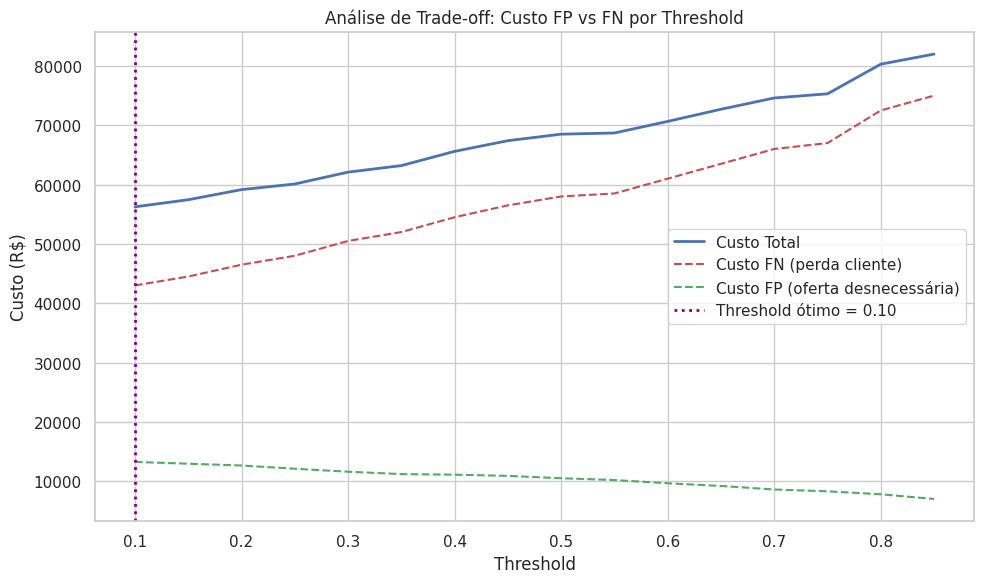

In [10]:
# Visualizar trade-off
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(cost_df['threshold'], cost_df['total_cost'], 'b-', linewidth=2, label='Custo Total')
ax.plot(cost_df['threshold'], cost_df['cost_fn'], 'r--', linewidth=1.5, label='Custo FN (perda cliente)')
ax.plot(cost_df['threshold'], cost_df['cost_fp'], 'g--', linewidth=1.5, label='Custo FP (oferta desnecessária)')
ax.axvline(x=optimal_threshold, color='purple', linestyle=':', linewidth=2,
           label=f'Threshold ótimo = {optimal_threshold:.2f}')
ax.set_xlabel('Threshold')
ax.set_ylabel('Custo (R$)')
ax.set_title('Análise de Trade-off: Custo FP vs FN por Threshold')
ax.legend()
plt.tight_layout()
plt.savefig('../docs/cost_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Conclusões

### Resultados:
- A MLP superou/competiu com os baselines em AUC-ROC e F1
- Early stopping evitou overfitting (convergência estável)
- Class weight melhorou recall sem sacrificar muito precision

### Trade-off de Custo:
- Threshold padrão (0.5) pode não ser ideal para o negócio
- Threshold ótimo minimiza o custo total considerando a assimetria FP/FN
- Recomendação: usar threshold que maximiza saving de retenção